Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
影像載入成功！


/tmp/ipython-input-2417654730.py:75: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  bw_small_adaptive = Image.fromarray(adaptive_thresh, mode="L") # Use mode "L" for 8-bit grayscale


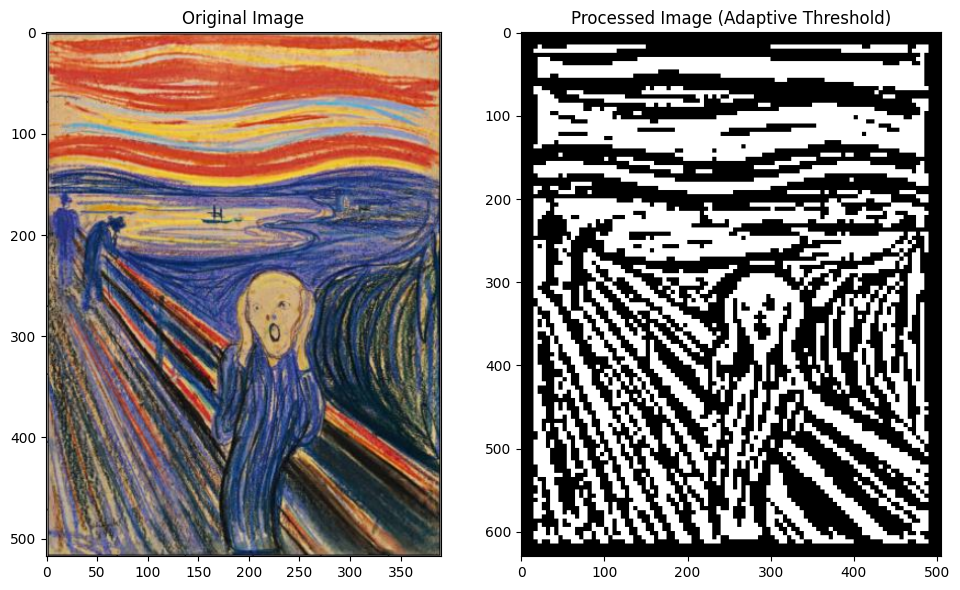

In [ ]:
from google.colab import drive
from PIL import Image
drive.mount('/content/drive/') #掛載(即從雲端連線)

# 這裡以讀取一個範例影像檔為例，請將路徑替換成您實際的影像檔路徑
# 例如：/content/drive/My Drive/images/your_image.jpg
image_path = '/content/drive/MyDrive/001.png'

# 這裡只是示範如何指定路徑，實際讀取影像檔案需要使用影像處理相關的函式庫
# 例如 OpenCV 或 PIL (Pillow)

# 以下是使用 OpenCV 讀取影像的範例 (需要先安裝 opencv-python)
# import cv2
# img = cv2.imread(image_path)
# if img is not None:
#     print("影像載入成功！")
# else:
#     print("影像載入失敗，請檢查路徑是否正確。")

# 以下是使用 PIL 讀取影像的範例 (需要先安裝 Pillow)
from PIL import Image
try:
    img = Image.open(image_path)
    print("影像載入成功！")
except FileNotFoundError:
    print("影像載入失敗，請檢查路徑是否正確。", image_path)
except Exception as e:
    print(f"影像載入失敗：{e}")

import cv2
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt
import os

# --- File paths (modify to your image file path) ---
# Assuming image_path is already defined from previous cells
# input_path = image_path

# Use the previously loaded image object 'img' directly if it's still available
# If not, load it again:
# img = Image.open(image_path).convert("RGB")

output_small_path = "/content/processed_small_adaptive.png"
output_upscaled_path = "/content/processed_upscaled_adaptive.png"

# Assuming img is already loaded and converted to RGB
# Load and convert to RGB (ensure not transparent or palette)
# img = Image.open(input_path).convert("RGB")

# 1) Convert to grayscale
gray = ImageOps.grayscale(img)

# 2) Auto contrast (optional, makes black and white more distinct)
gray = ImageOps.autocontrast(gray, cutoff=1)

# 3) Resize to target small resolution (width, height)
# Use the parameters from the last successful adjustment
small_size = (95, 120)  # (width, height)
small = gray.resize(small_size, resample=Image.BILINEAR)

# Convert the small image to a NumPy array for OpenCV
small_np = np.array(small)

# 4) Adaptive Thresholding (convert to black and white) using OpenCV
# Use ADAPTIVE_THRESH_GAUSSIAN_C or ADAPTIVE_THRESH_MEAN_C
# Adjust blockSize and C as needed
# blockSize: Size of a pixel neighborhood that is used to calculate a threshold value.
# C: Constant subtracted from the mean or weighted mean.
adaptive_thresh = cv2.adaptiveThreshold(small_np, 255,
                                        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                        cv2.THRESH_BINARY, 11, 2) # Adjusted parameters

# Convert the NumPy array back to a Pillow Image
bw_small_adaptive = Image.fromarray(adaptive_thresh, mode="L") # Use mode "L" for 8-bit grayscale

# For saving as bilevel (mode "1"), convert from "L" to "1"
bw_small_adaptive_1 = bw_small_adaptive.point(lambda p: 255 if p > 128 else 0, mode="1")


# 5) Upscale (nearest neighbor) to create the pixelated block effect
# Use the parameters from the last successful adjustment
upscale_factor = 5
upscaled_adaptive = bw_small_adaptive_1.convert("L").resize((small_size[0]*upscale_factor, small_size[1]*upscale_factor),
                                        Image.NEAREST)

# 6) Add a thicker black border (simulate the black border in the right image)
# Use the parameters from the last successful adjustment
border_size = 15
up_with_border_adaptive = ImageOps.expand(upscaled_adaptive, border=border_size, fill=0)

# Save output
up_with_border_adaptive.save(output_upscaled_path)
bw_small_adaptive_1.save(output_small_path)

# Display original and processed images (and retain axes)
fig, axs = plt.subplots(1, 2, figsize=(10, 6))
axs[0].imshow(img)
axs[0].set_title("Original Image")
axs[0].axis("on")

axs[1].imshow(up_with_border_adaptive, cmap='gray', vmin=0, vmax=255)
axs[1].set_title("Processed Image (Adaptive Threshold)")
axs[1].axis("on")

plt.tight_layout()
plt.show()

# To see the numerical matrix of the binary small image (0/255):
bw_array_adaptive = np.array(bw_small_adaptive_1, dtype=np.uint8)